In [1]:
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import plotly.colors as pc
from collections import Counter
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy as scipy_entropy

In [2]:


# --------------------------------------------------
# Style
# --------------------------------------------------

sns.set_style("white")
sns.set_context("talk")


# --------------------------------------------------
# File paths
# --------------------------------------------------

mouse_files = {
    "DLS Inhibition Mouse": r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\042126_m2_dls_3d_arena_h_cluster_output\Combined_Results\Results\test1\Cluster_detail_results.csv",
}



In [25]:

# --------------------------------------------------
# Load + label data
# --------------------------------------------------

def load_mouse_data(file_path, mouse_name):
    df = pd.read_csv(file_path)

    df = df[["ClusterIdx", "Timestamp", "Folder_Name"]].copy()
    df = df.dropna(subset=["ClusterIdx", "Timestamp", "Folder_Name"])
    df["Folder_Name"] = df["Folder_Name"].replace({
        1.0: "Baseline",
        2.0: "Inhibition",
    })

    df["ClusterIdx"] = pd.to_numeric(df["ClusterIdx"], errors="coerce")
    df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["ClusterIdx", "Timestamp"])

    df["ClusterIdx"] = df["ClusterIdx"].astype(int)
    df["Folder_Name"] = df["Folder_Name"].astype(str).str.strip()
    df["Mouse"] = mouse_name

    folder = df["Folder_Name"].str.lower()
    df["Arena"] = np.select(
        [
            folder.str.contains("baseline", na=False),
            folder.str.contains("inhibition", na=False),
        ],
        [
            "Baseline",
            "Inhibition",
        ],
        default="Unknown"
    )

    df = df.sort_values(["Folder_Name", "Timestamp"]).reset_index(drop=True)
    return df


# --------------------------------------------------
# Load all mice
# --------------------------------------------------

all_dfs = []

for mouse_name, file_path in mouse_files.items():
    df_mouse = load_mouse_data(file_path, mouse_name)
    all_dfs.append(df_mouse)

df_all = pd.concat(all_dfs, ignore_index=True)

print("\n================ DATA CHECK ================\n")
print("Total rows:", len(df_all))
print("Clusters:", df_all["ClusterIdx"].nunique())

print("\nArena counts:")
print(df_all["Arena"].value_counts())

print("\nArena by mouse:")
print(df_all.groupby(["Mouse", "Arena"]).size())



================ DATA CHECK ================

Total rows: 29647
Clusters: 49

Arena counts:
Arena
Inhibition    17700
Baseline      11947
Name: count, dtype: int64

Arena by mouse:
Mouse                 Arena     
DLS Inhibition Mouse  Baseline      11947
                      Inhibition    17700
dtype: int64


In [26]:


# --------------------------------------------------
# Transition helpers
# --------------------------------------------------

def create_transitions(data, include_self_transitions=False):
    transitions = Counter()

    data = data.sort_values("Timestamp")
    clusters = data["ClusterIdx"].to_numpy()

    if len(clusters) < 2:
        return transitions

    for i in range(len(clusters) - 1):
        c1 = clusters[i]
        c2 = clusters[i + 1]

        if not include_self_transitions and c1 == c2:
            continue

        transitions[(c1, c2)] += 1

    return transitions


def pooled_transitions(df, include_self_transitions=False):
    total = Counter()

    for _, session_df in df.groupby("Folder_Name"):
        total.update(
            create_transitions(
                session_df,
                include_self_transitions=include_self_transitions
            )
        )

    return dict(total)


def transitions_to_matrix(transitions, cluster_list):
    mat = pd.DataFrame(
        0,
        index=cluster_list,
        columns=cluster_list,
        dtype=float
    )

    for (c1, c2), count in transitions.items():
        if c1 in mat.index and c2 in mat.columns:
            mat.loc[c1, c2] = count

    return mat


def normalize(mat):
    row_sums = mat.sum(axis=1).replace(0, np.nan)
    return mat.div(row_sums, axis=0).fillna(0)


def transition_probability_dict(transitions):
    total = sum(transitions.values())

    if total == 0:
        return {}

    return {
        transition: count / total
        for transition, count in transitions.items()
    }


In [27]:

# --------------------------------------------------
# 4F Shared-Motif-Only Heatmaps
# Separate figures
# --------------------------------------------------

def get_shared_transition_mats(trans_a, trans_b):
    shared = set(trans_a.keys()).intersection(set(trans_b.keys()))

    if len(shared) == 0:
        return None, None

    shared_a = {k: trans_a[k] for k in shared}
    shared_b = {k: trans_b[k] for k in shared}

    clusters = sorted(set([c for pair in shared for c in pair]))

    mat_a = normalize(transitions_to_matrix(shared_a, clusters))
    mat_b = normalize(transitions_to_matrix(shared_b, clusters))

    return mat_a, mat_b


def plot_single_shared_heatmap(mat, title):
    plt.figure(figsize=(10, 8))

    if mat is None or mat.empty:
        plt.text(
            0.5,
            0.5,
            "No shared motifs",
            ha="center",
            va="center",
            fontsize=16
        )
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        return

    vmax = mat.to_numpy().max()

    if vmax == 0:
        vmax = 1

    cmap = sns.light_palette("blue", as_cmap=True)

    sns.heatmap(mat, cmap=cmap, vmin=0, vmax=vmax)
    plt.title(title)
    plt.xlabel("To Cluster")
    plt.ylabel("From Cluster")
    plt.tight_layout()
    plt.show()

In [28]:

def plot_4f_shared_heatmaps_for_mouse(df_mouse, mouse_name):
    df_flat = df_mouse[df_mouse["Arena"] == "Baseline"].copy()
    flat_trans = pooled_transitions(df_flat, include_self_transitions=False)

    comparisons = [
        ("Inhibition", df_mouse[df_mouse["Arena"] == "Inhibition"].copy()),
    ]

    for label, df_group in comparisons:
        print(f"\nMaking 4F shared heatmaps for {mouse_name}: Baseline vs {label}")

        group_trans = pooled_transitions(df_group, include_self_transitions=False)

        group_mat, flat_mat = get_shared_transition_mats(
            group_trans,
            flat_trans
        )

        plot_single_shared_heatmap(
            group_mat,
            f"4F {mouse_name}: Baseline vs {label} - {label} Shared-Motif Heatmap"
        )

        plot_single_shared_heatmap(
            flat_mat,
            f"4F {mouse_name}: Baseline vs {label} - Flat Shared-Motif Heatmap"
        )



In [30]:

# --------------------------------------------------
# Jensen-Shannon Divergence
# --------------------------------------------------

def transitions_to_prob_vector(transitions, all_keys):
    total = sum(transitions.values())

    if total == 0:
        return np.zeros(len(all_keys))

    return np.array([
        transitions.get(k, 0) / total
        for k in all_keys
    ])


def compute_js_divergence(trans_a, trans_b):
    all_keys = list(set(trans_a.keys()).union(set(trans_b.keys())))

    if len(all_keys) == 0:
        print("List 'all_keys' has a length of 0")
        return np.nan

    p = transitions_to_prob_vector(trans_a, all_keys)
    q = transitions_to_prob_vector(trans_b, all_keys)

    js_distance = jensenshannon(p, q)
    js_divergence = js_distance ** 2

    return js_divergence


def compute_transition_entropy(transitions):
    """Shannon entropy (bits) of the transition probability distribution."""
    total = sum(transitions.values())
    if total == 0:
        return np.nan
    probs = np.array(list(transitions.values())) / total
    return scipy_entropy(probs, base=2)  # bits; drop base=2 for nats

# --------------------------------------------------
# Compute JS divergence by mouse
# --------------------------------------------------

js_rows = []
entropy_rows = []

arena_order = ["Baseline", "Inhibition"]

for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()

    df_flat = df_mouse[df_mouse["Arena"] == "Baseline"].copy()
    df_3d = df_mouse[df_mouse["Arena"] == "Inhibition"].copy()

    flat_trans = pooled_transitions(df_flat, include_self_transitions=False)
    d3_trans = pooled_transitions(df_3d, include_self_transitions=False)

    js_rows.append({
        "Mouse": mouse_name,
        "Comparison": "Baseline vs Inhibition",
        "JS Divergence": compute_js_divergence(flat_trans, d3_trans)
    })
    for condition_label, condition_key in [("Baseline", "Baseline"), ("Inhibition", "Inhibition")]:
        df_cond = df_mouse[df_mouse["Arena"] == condition_key].copy()
        trans = pooled_transitions(df_cond, include_self_transitions=False)
        entropy_rows.append({
            "Mouse": mouse_name,
            "Arena": condition_label,
            "Entropy (bits)": compute_transition_entropy(trans)
        })

    for arena in arena_order:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans = pooled_transitions(df_arena, include_self_transitions=False)

        entropy_rows.append({
            "Mouse": mouse_name,
            "Arena": arena,
            "Entropy (bits)": compute_transition_entropy(arena_trans)
        })

df_js = pd.DataFrame(js_rows)
df_entropy = pd.DataFrame(entropy_rows)

print("\n================ JS DIVERGENCE TABLE ================\n")
print(df_js)

print("\n================ ENTROPY TABLE ================\n")
print(df_entropy)


================ JS DIVERGENCE TABLE ================

                  Mouse              Comparison  JS Divergence
0  DLS Inhibition Mouse  Baseline vs Inhibition       0.124476

================ ENTROPY TABLE ================

                  Mouse       Arena  Entropy (bits)
0  DLS Inhibition Mouse    Baseline        9.527448
1  DLS Inhibition Mouse  Inhibition        9.780232
2  DLS Inhibition Mouse    Baseline        9.527448
3  DLS Inhibition Mouse  Inhibition        9.780232


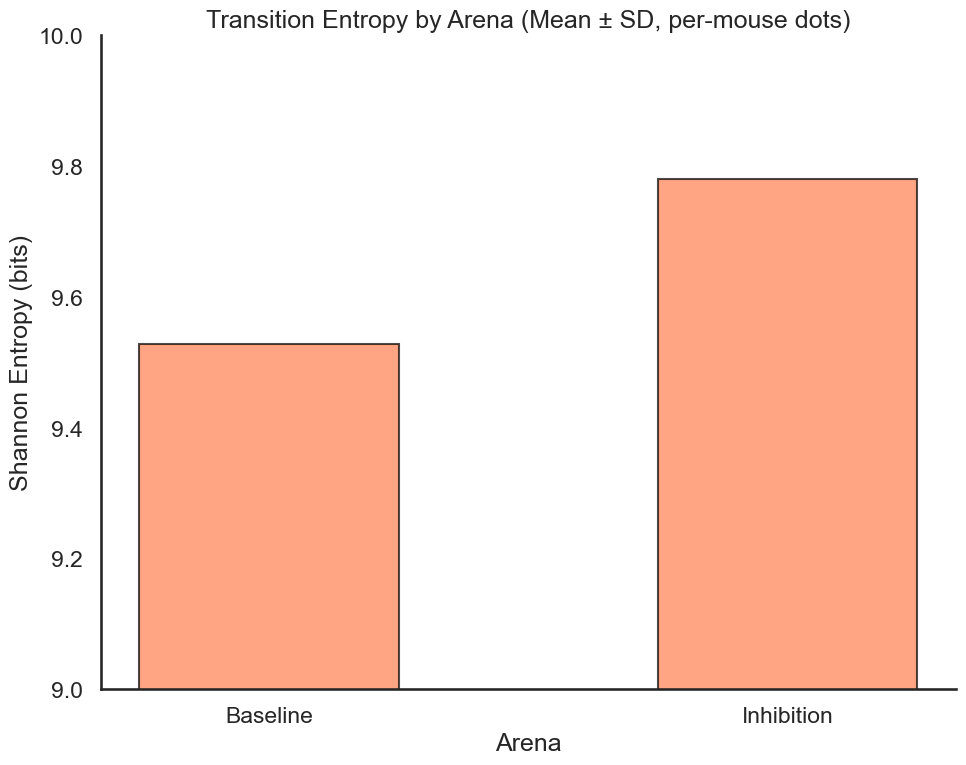

In [63]:

arena_order_plot = ["Baseline", "Inhibition"]

# Filter to only arenas that exist in the data
existing_arenas = df_entropy["Arena"].unique()
plot_order = [a for a in arena_order_plot if a in existing_arenas]

plt.figure(figsize=(10, 8))
ax = plt.gca()

# --- Bar: group mean ---
df_grouped = df_entropy.groupby("Arena")["Entropy (bits)"].agg(["mean", "std"]).reindex(plot_order)

x_pos = np.arange(len(plot_order))
bar_width = 0.5

ax.bar(
    x_pos,
    df_grouped["mean"],
    width=bar_width,
    color="coral",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    zorder=2
)

# --- Error bars: std ---
# ax.errorbar(
#     x_pos,
#     df_grouped["mean"],
#     yerr=df_grouped["std"],
#     fmt="none",
#     color="black",
#     capsize=5,
#     linewidth=1.5,
#     zorder=3
# )

# --- Dots: individual mice ---
mice = df_entropy["Mouse"].unique()
colors = sns.color_palette("tab10", n_colors=len(mice))
mouse_color = dict(zip(mice, colors))

# for arena_idx, arena in enumerate(plot_order):
#     df_arena = df_entropy[df_entropy["Arena"] == arena]
#     for _, row in df_arena.iterrows():
#         ax.scatter(
#             arena_idx,
#             row["Entropy (bits)"],
#             color=mouse_color[row["Mouse"]],
#             s=80,
#             zorder=4,
#             edgecolors="white",
#             linewidths=0.5
#         )

# # --- Legend for mice ---
# handles = [
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=mouse_color[m],
#                markersize=9, label=m)
#     for m in mice
# ]
# ax.legend(handles=handles, title="Mouse", bbox_to_anchor=(1.01, 1), loc="upper left")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_order)
                   #, rotation=45, ha="right")
ax.set_xlabel("Arena")
ax.set_ylabel("Shannon Entropy (bits)")
ax.set_title("Transition Entropy by Arena (Mean ± SD, per-mouse dots)")
ax.set_ylim(9,10)
sns.despine()
plt.tight_layout()
plt.savefig("transition_entropy_by_arena.png", dpi=300)
plt.show()

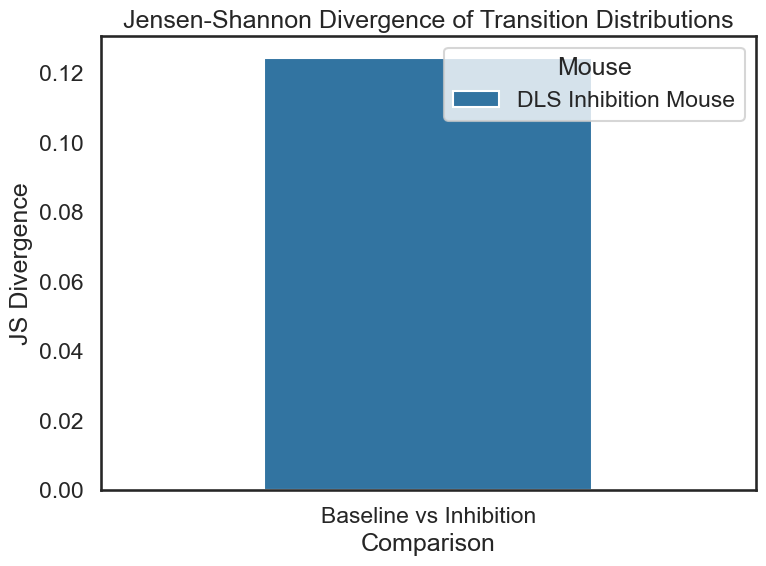

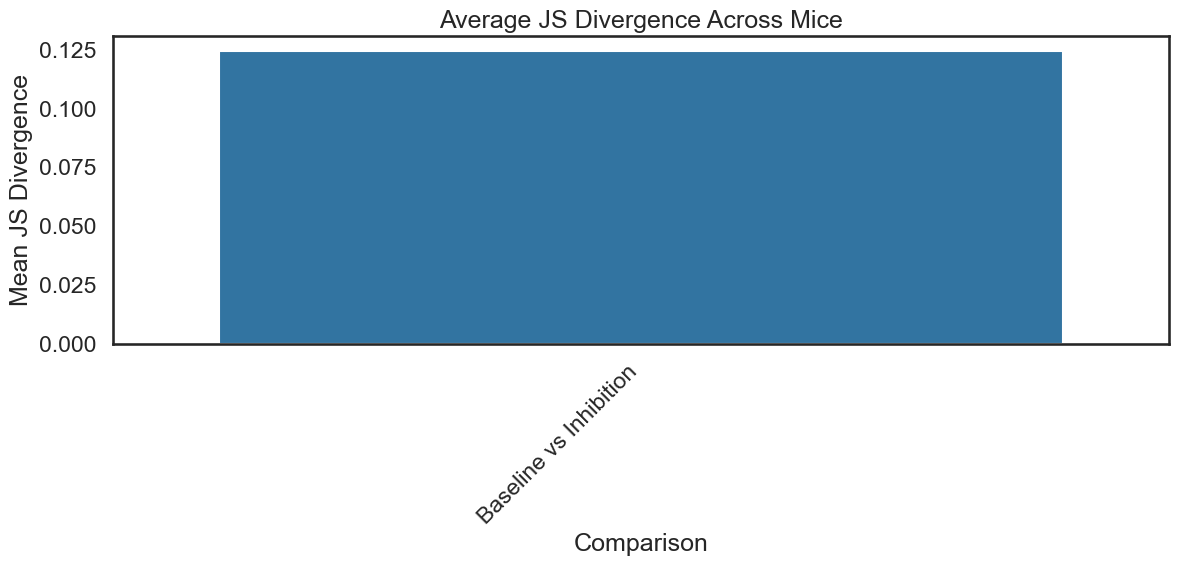

In [69]:
# --------------------------------------------------
# JS divergence bar graph by mouse
# --------------------------------------------------

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_js,
    width=.5,
    x="Comparison",
    y="JS Divergence",
    hue="Mouse"
)

plt.title("Jensen-Shannon Divergence of Transition Distributions")
plt.xlabel("Comparison")
plt.ylabel("JS Divergence")
#plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"JS Divergence of Transition Distributions.png", dpi=300)
plt.show()


# --------------------------------------------------
# Average JS divergence across mice
# --------------------------------------------------

df_js_avg = (
    df_js
    .groupby("Comparison", as_index=False)["JS Divergence"]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_js_avg,
    x="Comparison",
    y="JS Divergence"
)

plt.title("Average JS Divergence Across Mice")
plt.xlabel("Comparison")
plt.ylabel("Mean JS Divergence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [75]:
def plot_transition_graph(
    subset_transition_matrix,
    transitions=40,
    node_scaling=4,
    edge_scaling=6,
    text_scaling=0.4,
    arrow_reduction_factor=0.03,
    title="Transition Graph",
    colorscale="Blues",
    save=False,
    path=None,
    export_csv=False,
    csv_path=None
):
    import plotly.colors as pc

    def weight_to_color(w, vmin, vmax):
        if vmax == vmin:
            return "rgb(8,48,107)"
        norm = (w - vmin) / (vmax - vmin)
        return pc.sample_colorscale(colorscale, norm)[0]

    edges = []

    for i in subset_transition_matrix.index:
        for j in subset_transition_matrix.columns:
            weight = subset_transition_matrix.loc[i, j]
            if weight > 0 and i != j:
                edges.append((str(i), str(j), float(weight)))

    if len(edges) == 0:
        print(f"No nonzero transitions found for: {title}")
        return

    top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:transitions]

    top_nodes = set(
        [u for u, v, w in top_edges]
        + [v for u, v, w in top_edges]
    )

    G = nx.DiGraph()
    G.add_nodes_from(top_nodes)

    for u, v, w in top_edges:
        G.add_edge(u, v, weight=w)

    if G.number_of_nodes() == 0:
        print(f"No graph created for: {title}")
        return

    ordered_nodes = sorted(G.nodes(), key=lambda x: int(float(x)))
    pos = nx.circular_layout(ordered_nodes)

    node_degrees = dict(G.degree())

    # node_size = [
    #     max(node_degrees[node] * node_scaling + 18, 18)
    #     for node in G.nodes()
    # ]
    node_size = [48 for node in G.nodes()]

    # text_size = [
    #     max(node_degrees[node] * text_scaling + 5, 5)
    #     for node in G.nodes()
    # ]
    text_size = [18 for node in G.nodes()]
    pixel_to_coord = 2.4 / 800

    node_radius = [
        size * pixel_to_coord * 0.5
        for size in node_size
    ]

    node_radii = {
        node: r
        for node, r in zip(G.nodes(), node_radius)
    }

    # --- color range from edge weights ---
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    vmin_w = min(edge_weights)
    vmax_w = max(edge_weights)

    node_degrees = dict(G.degree())
    degree_values = [node_degrees[node] for node in G.nodes()]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes()],
        y=[pos[node][1] for node in G.nodes()],
        text=[str(int(float(node))) for node in G.nodes()],
        mode="markers+text",
        hoverinfo="text",
        marker=dict(
            size=48,                      # uniform size
            color=degree_values,          # degree encoded as color
            colorscale=[
                [0.0, "rgb(255,245,240)"],   # lightest
                [1.0, "rgb(186, 25, 6)"]      # max — bright red but not too dark
            ],
            showscale=True,
            colorbar=dict(title="Degree"),
            cmin=0,       # min degree
            cmax=10,      # max degree — adjust to your data
            line=dict(width=1, color="black")
        ),
        textfont=dict(size=18, color="black")
    )

    edge_traces = []

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0

        dist = np.sqrt(dx * dx + dy * dy)

        if dist == 0:
            continue

        x_start = x0 + dx * (node_radii[u] / dist)
        y_start = y0 + dy * (node_radii[u] / dist)
        x_end   = x1 - dx * (node_radii[v] / dist) - dx * arrow_reduction_factor
        y_end   = y1 - dy * (node_radii[v] / dist) - dy * arrow_reduction_factor

        edge_traces.append(
            go.Scatter(
                x=[x_start, x_end, None],
                y=[y_start, y_end, None],
                line=dict(width=2, color=color),
                hoverinfo="text",
                text=[f"{u} → {v}<br>p={edge_weight:.3f}"],
                mode="lines"
            )
        )

    fig = go.Figure(data=[*edge_traces, node_trace])

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0
        dist = (dx ** 2 + dy ** 2) ** 0.5

        x1_arrow = x1 - dx * arrow_reduction_factor if dist > 0 else x1
        y1_arrow = y1 - dy * arrow_reduction_factor if dist > 0 else y1

        fig.add_annotation(
            ax=x0,
            ay=y0,
            x=x1_arrow,
            y=y1_arrow,
            xref="x",
            yref="y",
            axref="x",
            ayref="y",
            showarrow=True,
            arrowhead=2,
            arrowsize=0.8,
            arrowwidth=2,
            arrowcolor=color
        )

    fig.update_layout(
        title={
            "text": title,
            "font": {"size": 16}
        },
        width=900,
        height=900,
        paper_bgcolor="#d9dde3",
        plot_bgcolor="#d9dde3",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=10, l=10, r=10, t=40),
        xaxis=dict(
            range=[-1.15, 1.15],
            showgrid=False,
            zeroline=False,
            showticklabels=False
        ),
        yaxis=dict(
            range=[-1.15, 1.15],
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False
        )
    )

    if save and path:
        base_path, _ = os.path.splitext(path)
        #fig.write_html(f"{base_path}.html")
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    if export_csv and csv_path:
        node_sizes = {
            node: max(node_degrees[node] * node_scaling + 18, 18)
            for node in G.nodes()
        }

        with open(csv_path, mode="w", newline="") as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(
                ["starting cluster", "ending cluster", "edge weight", "node size"]
            )

            for u, v, w in top_edges:
                node_size_u = node_sizes.get(u, 18)
                csvwriter.writerow([u, v, w, node_size_u])

        print(f"CSV file '{csv_path}' has been created with {len(top_edges)} edges.")

    fig.show()

In [87]:
def plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=40, save=False):
    """
    Three transition graphs using all transitions present in ANY arena in the group:
      - Combined: all 5 arenas (Restricted, Non-restricted, Low, Medium, High)
      - 2D:       Restricted + Non-restricted
      - 3D:       Low + Medium + High
    Edge weights reflect combined frequency across the relevant arenas.
    """

    arena_groups = {
        "Combined": ["Baseline", "Inhibition"],
        "Baseline": ["Baseline"],
        "Inhibition":   ["Inhibition"],
    }

    # --- get per-arena transitions ---
    arena_trans = {}
    for arena in ["Baseline", "Inhibition"]:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans[arena] = pooled_transitions(df_arena, include_self_transitions=False)

    for group_label, arenas in arena_groups.items():

        # --- union: all transitions present in ANY arena in the group ---
        trans_sets = [set(arena_trans[a].keys()) for a in arenas]
        all_keys = set.union(*trans_sets)

        if len(all_keys) == 0:
            print(f"No transitions found for {mouse_name} - {group_label}")
            continue

        # --- combined counts across all arenas in the group ---
        combined_counts = Counter()
        for arena in arenas:
            for k in all_keys:
                combined_counts[k] += arena_trans[arena].get(k, 0)

        # --- normalize to get probabilities ---
        total = sum(combined_counts.values())
        combined_trans = {k: v / total for k, v in combined_counts.items()}

        # --- build matrix ---
        clusters = sorted(set(c for pair in all_keys for c in pair))
        mat = pd.DataFrame(0.0, index=clusters, columns=clusters)

        for (c1, c2), w in combined_trans.items():
            mat.loc[c1, c2] = w

        # --- rescale weights to [0, 1] so edge thickness variation is visible ---
        vals = mat.values
        vmin, vmax = vals.min(), vals.max()

        if vmax > vmin:
            mat = (mat - vmin) / (vmax - vmin)
        else:
            print(f"All edge weights identical for {mouse_name} - {group_label}, skipping rescale")

        print(f"\n{mouse_name} - {group_label}: {len(all_keys)} transitions")

        title=f"{mouse_name}-{group_label} Shared Transition Graph"
        plot_transition_graph(
            mat,
            transitions=graph_top_n,
            title=title,
            save=save,
            path=f"{title.replace(' ', '_')}"
        )
        break

In [89]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=1580, save=True)
    break


DLS Inhibition Mouse - Combined: 1580 transitions


In [57]:
def plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition (Baseline or Inhibition),
    then finds those same transitions in the other condition.
    Plots a grouped bar chart side by side.

    Parameters
    ----------
    reference : str
        "Baseline" to rank by Baseline transitions, "Inhibition" to rank by Inhibition transitions.
    """

    if reference == "Baseline":
        ref_label  = "Baseline"
        comp_label = "Inhibition"
    elif reference == "Inhibition":
        ref_label  = "Inhibition"
        comp_label = "Baseline"
    else:
        raise ValueError(f"reference must be 'Baseline' or 'Inhibition', got '{reference}'")

    arena_groups = {
        "Baseline": ["Baseline"],
        "Inhibition": ["Inhibition"],
    }

    # --- pool transitions per group ---
    group_trans = {}
    for group_label, arenas in arena_groups.items():
        combined = Counter()
        for arena in arenas:
            df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
            combined.update(pooled_transitions(df_arena, include_self_transitions=False))
        group_trans[group_label] = dict(combined)

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs_ref  = to_probs(group_trans[ref_label])
    probs_comp = to_probs(group_trans[comp_label])

    if len(probs_ref) == 0:
        print(f"No {ref_label} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs_ref, key=probs_ref.get, reverse=True)[:top_n]

    labels    = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref  = [probs_ref.get(t, 0)  for t in top_transitions]
    vals_comp = [probs_comp.get(t, 0) for t in top_transitions]

    # --- plot ---
    x = np.arange(len(labels))
    bar_width = 0.35

    ref_color  = "steelblue" if ref_label  == "Baseline" else "white"
    comp_color = "steelblue" if comp_label == "Baseline" else "white"

    fig, ax = plt.subplots(figsize=(14, 7))

    ax.bar(x - bar_width / 2, vals_ref,  width=bar_width, label=ref_label,  color=ref_color,  edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, vals_comp, width=bar_width, label=comp_label, color=comp_color, edgecolor="black", linewidth=0.8)

    # --- mark bars that are zero (transition absent in that condition) ---
    for i, v in enumerate(vals_comp):
        if v == 0:
            ax.text(
                x[i] + bar_width / 2,
                0.0005,
                "n/a",
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel("Transition Probability")
    ax.set_title(f"{mouse_name} — Top {top_n} {ref_label} Transitions vs {comp_label}")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":               labels,
        f"{ref_label} Probability":  vals_ref,
        f"{comp_label} Probability": vals_comp,
        f"In {comp_label}":         ["Yes" if v > 0 else "No" for v in vals_comp]
    })
    print(f"\n{mouse_name} — Top {top_n} {ref_label} Transitions vs {comp_label}")
    print(df_out.to_string(index=False))

    return df_out

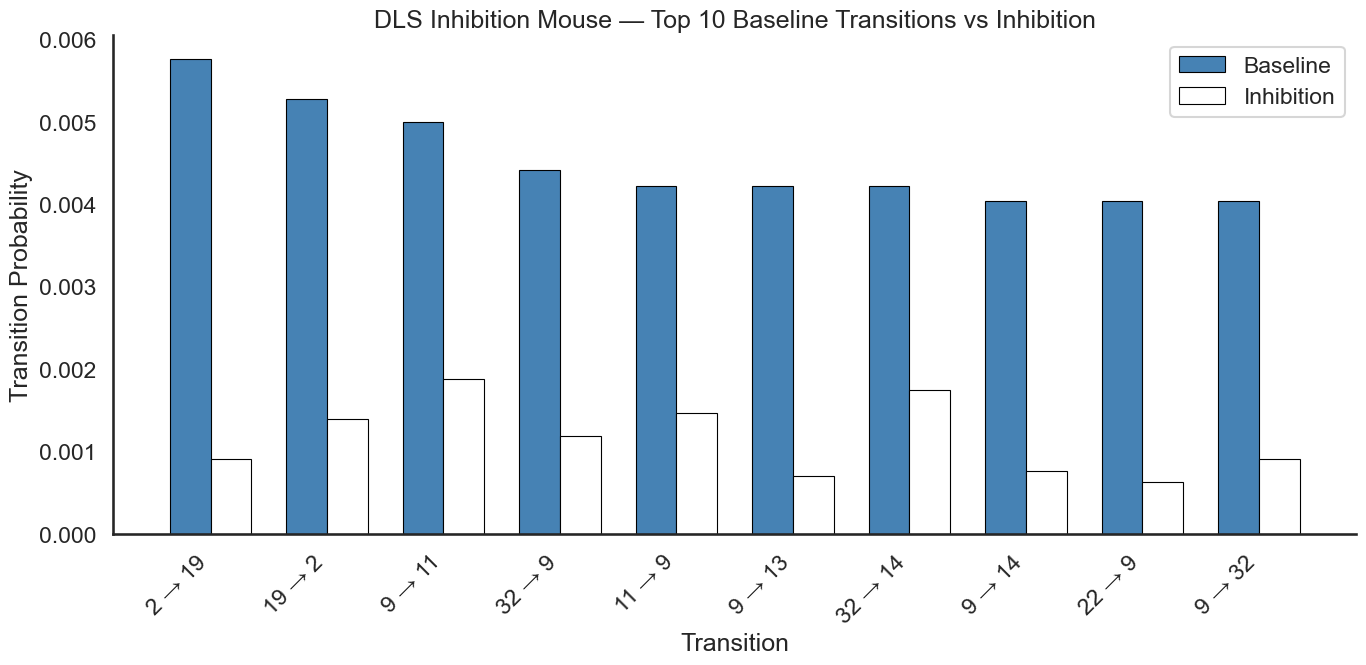


DLS Inhibition Mouse — Top 10 Baseline Transitions vs Inhibition
Transition  Baseline Probability  Inhibition Probability In Inhibition
    2 → 19              0.005758                0.000905           Yes
    19 → 2              0.005278                0.001392           Yes
    9 → 11              0.004990                0.001880           Yes
    32 → 9              0.004414                0.001183           Yes
    11 → 9              0.004222                0.001462           Yes
    9 → 13              0.004222                0.000696           Yes
   32 → 14              0.004222                0.001740           Yes
    9 → 14              0.004030                0.000766           Yes
    22 → 9              0.004030                0.000627           Yes
    9 → 32              0.004030                0.000905           Yes


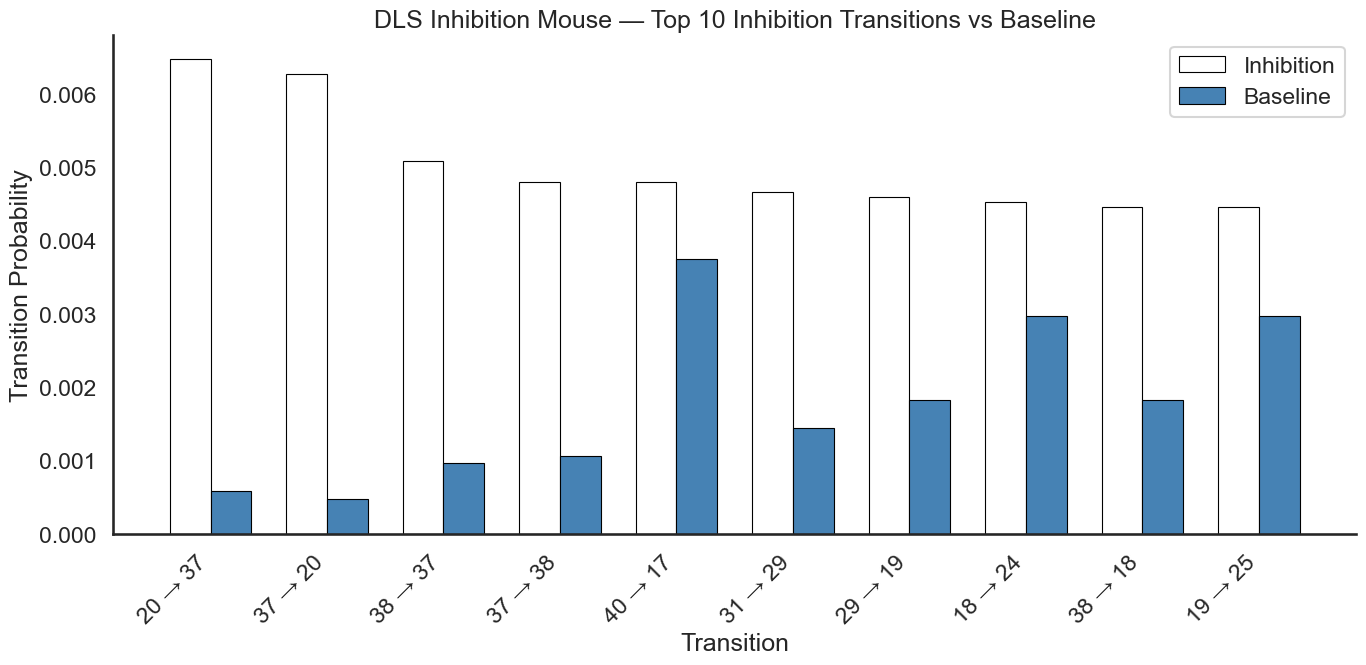


DLS Inhibition Mouse — Top 10 Inhibition Transitions vs Baseline
Transition  Inhibition Probability  Baseline Probability In Baseline
   20 → 37                0.006474              0.000576         Yes
   37 → 20                0.006265              0.000480         Yes
   38 → 37                0.005082              0.000960         Yes
   37 → 38                0.004803              0.001056         Yes
   40 → 17                0.004803              0.003742         Yes
   31 → 29                0.004664              0.001439         Yes
   29 → 19                0.004595              0.001823         Yes
   18 → 24                0.004525              0.002975         Yes
   38 → 18                0.004455              0.001823         Yes
   19 → 25                0.004455              0.002975         Yes


In [78]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_vs_Inhibition_top_transitions.png")
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_top_transitions.png")

In [ ]:
def plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=False):
    """
    Plots bar chart of counts for specified clusters across conditions.

    Parameters
    ----------
    df_mouse : pd.DataFrame
        DataFrame for a single mouse.
    mouse_name : str
        Name of the mouse (used in title).
    cluster_labels : list of int
        List of cluster labels to include, e.g. [2, 4, 6, 8].
    """

    
    #================= All Data Counts ================
    
    counts = df_mouse[df_mouse["ClusterIdx"].isin(cluster_labels)]["ClusterIdx"].value_counts()
    counts = counts.reindex(cluster_labels, fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        [str(c) for c in cluster_labels],
        counts.values,
        color="steelblue",
        edgecolor="black",
        linewidth=0.8,
        width=0.6,
    )

    title = f"{mouse_name} — Cluster Counts"
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.set_title(title)

    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"{title.replace(" ", '_')}.png", dpi=300)
    plt.show()

    arenas = ["Baseline", "Inhibition"]
    for arena in arenas:
        df_arena = df_mouse[df_mouse["Arena"] == arena]
        counts = df_arena[df_arena["ClusterIdx"].isin(cluster_labels)]["ClusterIdx"].value_counts()
        counts = counts.reindex(cluster_labels, fill_value=0)

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.bar(
            [str(c) for c in cluster_labels],
            counts.values,
            color="steelblue",
            edgecolor="black",
            linewidth=0.8,
            width=0.6,
        )
        
        title = f"{mouse_name} {arena}— Cluster Counts"
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Count")
        ax.set_title(title)

        sns.despine()
        plt.tight_layout()

        if save:
            plt.savefig(f"{title.replace(" ", '_')}.png", dpi=300)
        plt.show()

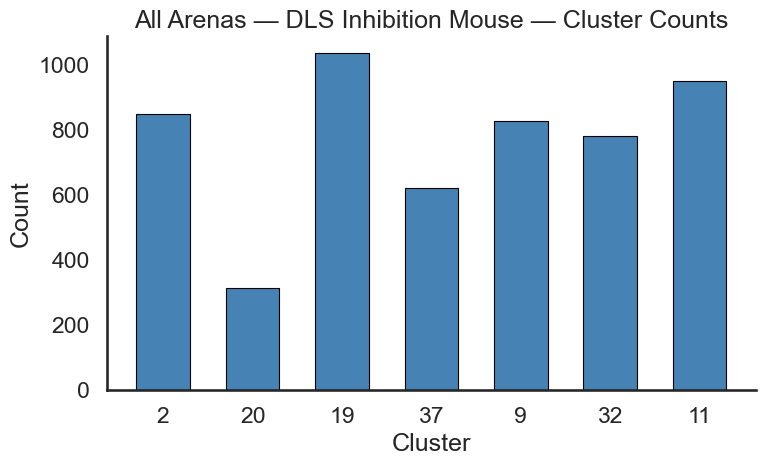

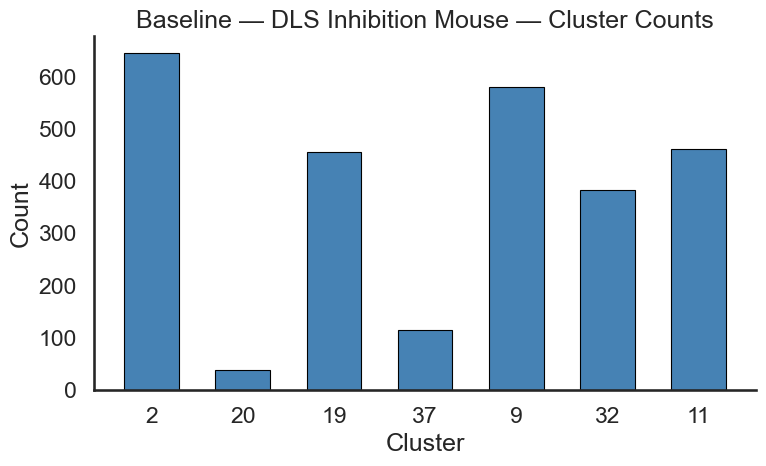

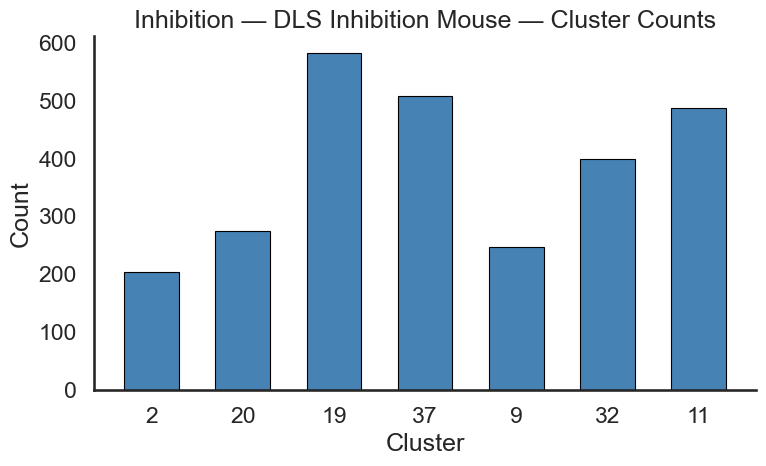

In [109]:
cluster_labels = [2, 20, 19, 37, 9, 32, 11]
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=True)

In [85]:
def plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition, then plots a single bar
    per transition showing the change in probability (Inhibition − Baseline).

    Bars above zero = transition becomes more likely under Inhibition.
    Bars below zero = transition becomes less likely under Inhibition.

    Parameters
    ----------
    reference : str
        "Baseline" to rank by Baseline transitions, "Inhibition" to rank by Inhibition transitions.
    """

    if reference == "Baseline":
        ref_label  = "Baseline"
        comp_label = "Inhibition"
    elif reference == "Inhibition":
        ref_label  = "Inhibition"
        comp_label = "Baseline"
    else:
        raise ValueError(f"reference must be 'Baseline' or 'Inhibition', got '{reference}'")

    arena_groups = {
        "Baseline":   ["Baseline"],
        "Inhibition": ["Inhibition"],
    }

    # --- pool transitions per group ---
    group_trans = {}
    for group_label, arenas in arena_groups.items():
        combined = Counter()
        for arena in arenas:
            df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
            combined.update(pooled_transitions(df_arena, include_self_transitions=False))
        group_trans[group_label] = dict(combined)

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs_ref  = to_probs(group_trans[ref_label])
    probs_comp = to_probs(group_trans[comp_label])

    if len(probs_ref) == 0:
        print(f"No {ref_label} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs_ref, key=probs_ref.get, reverse=True)[:top_n]

    labels    = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref  = [probs_ref.get(t, 0)  for t in top_transitions]
    vals_comp = [probs_comp.get(t, 0) for t in top_transitions]

    # --- compute % change: (comp − ref) / ref × 100 ---
    pct_changes = [
        ((vc - vr) / vr * 100) if vr > 0 else float("nan")
        for vr, vc in zip(vals_ref, vals_comp)
    ]

    # --- color bars by direction (skip NaN) ---
    bar_colors = [
        "steelblue" if (not np.isnan(d) and d >= 0) else "tomato"
        for d in pct_changes
    ]

    # --- plot ---
    x = np.arange(len(labels))
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(14, 7))

    bars = ax.bar(x, pct_changes, width=bar_width, color=bar_colors, edgecolor="black", linewidth=0.8)

    # --- zero reference line ---
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")

    # --- annotate bars where ref probability was zero (undefined % change) ---
    for i, (d, vr) in enumerate(zip(pct_changes, vals_ref)):
        if np.isnan(d):
            ax.text(x[i], 0.05, "n/a\n(ref=0)", ha="center", va="bottom", fontsize=8, color="gray")

    # --- legend proxy patches ---
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="steelblue",    edgecolor="black", label=f"Increase under {comp_label}"),
        Patch(facecolor="tomato", edgecolor="black", label=f"Decrease under {comp_label}"),
    ]
    ax.legend(handles=legend_elements)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel(f"% Change  ({comp_label} vs {ref_label})")
    ax.set_title(f"{mouse_name} — % Change in Top {top_n} {ref_label} Transition Probabilities")

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":                labels,
        f"{ref_label} Probability":  vals_ref,
        f"{comp_label} Probability": vals_comp,
        "% Change":                  [f"{d:+.1f}%" if not np.isnan(d) else "n/a" for d in pct_changes],
        "Direction":                 [
            "↑" if (not np.isnan(d) and d > 0) else ("↓" if (not np.isnan(d) and d < 0) else "=")
            for d in pct_changes
        ],
    })
    print(f"\n{mouse_name} — ΔP for Top {top_n} {ref_label} Transitions")
    print(df_out.to_string(index=False))

    return df_out

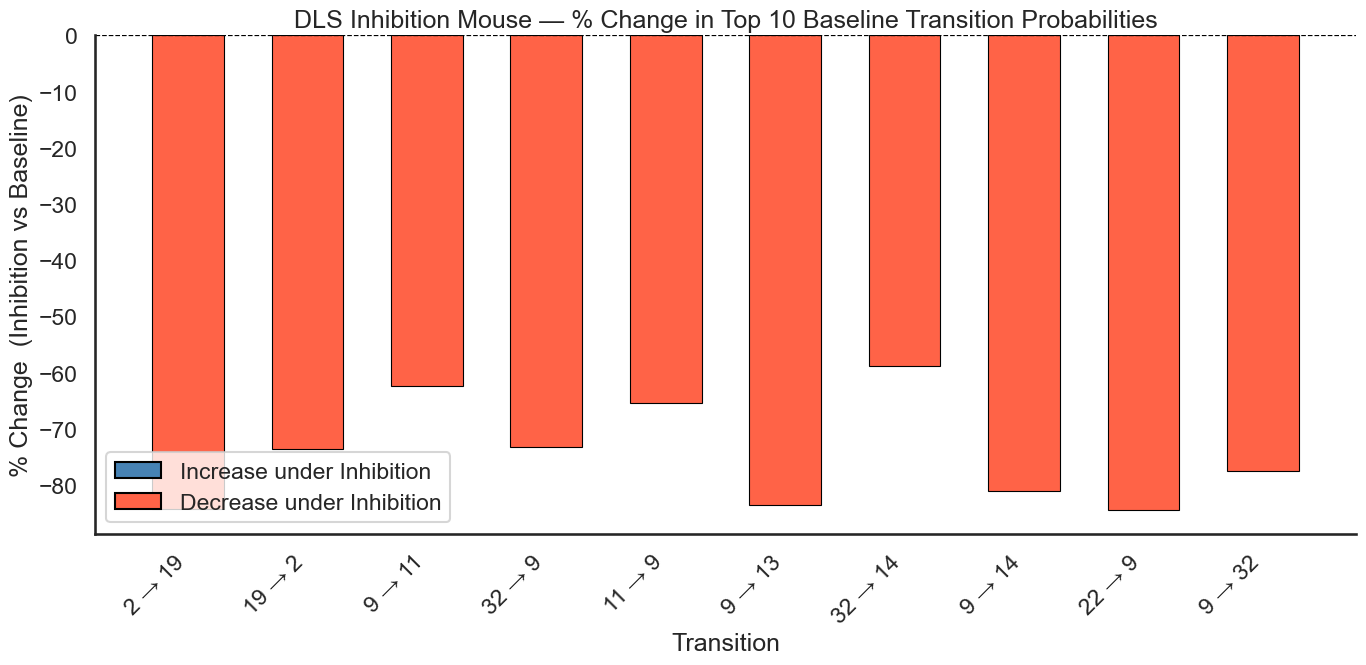


DLS Inhibition Mouse — ΔP for Top 10 Baseline Transitions
Transition  Baseline Probability  Inhibition Probability % Change Direction
    2 → 19              0.005758                0.000905   -84.3%         ↓
    19 → 2              0.005278                0.001392   -73.6%         ↓
    9 → 11              0.004990                0.001880   -62.3%         ↓
    32 → 9              0.004414                0.001183   -73.2%         ↓
    11 → 9              0.004222                0.001462   -65.4%         ↓
    9 → 13              0.004222                0.000696   -83.5%         ↓
   32 → 14              0.004222                0.001740   -58.8%         ↓
    9 → 14              0.004030                0.000766   -81.0%         ↓
    22 → 9              0.004030                0.000627   -84.5%         ↓
    9 → 32              0.004030                0.000905   -77.5%         ↓


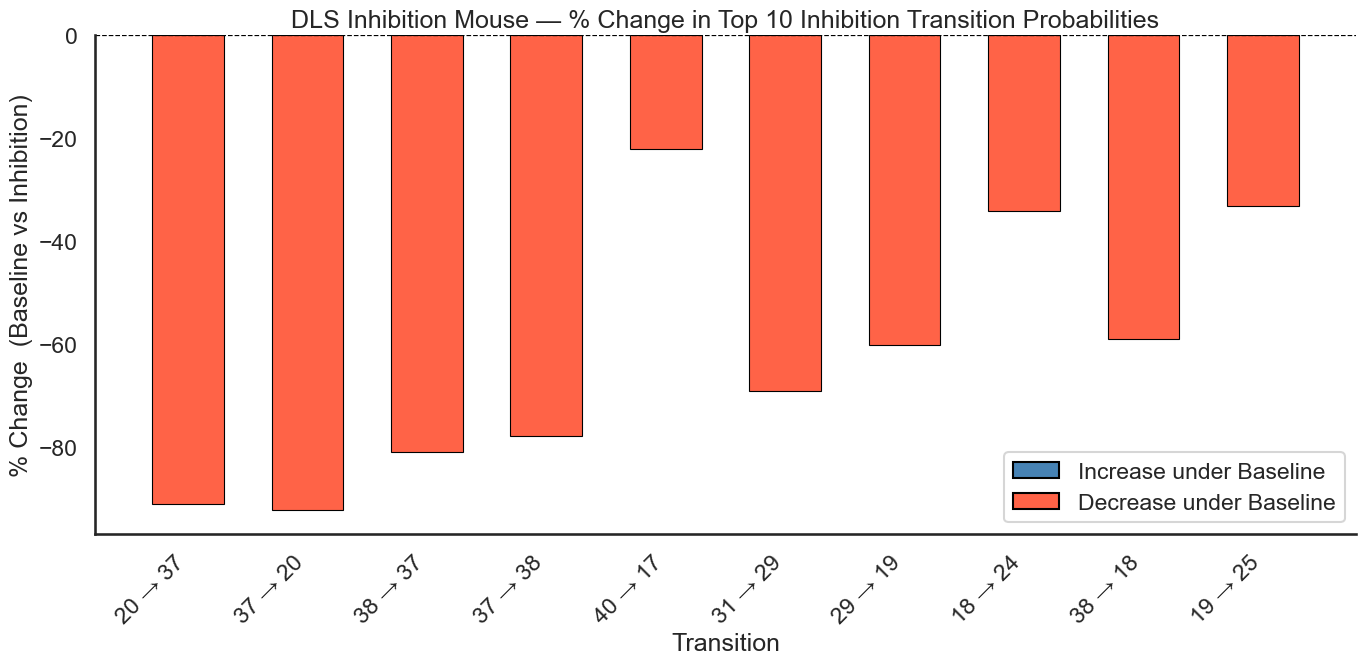


DLS Inhibition Mouse — ΔP for Top 10 Inhibition Transitions
Transition  Inhibition Probability  Baseline Probability % Change Direction
   20 → 37                0.006474              0.000576   -91.1%         ↓
   37 → 20                0.006265              0.000480   -92.3%         ↓
   38 → 37                0.005082              0.000960   -81.1%         ↓
   37 → 38                0.004803              0.001056   -78.0%         ↓
   40 → 17                0.004803              0.003742   -22.1%         ↓
   31 → 29                0.004664              0.001439   -69.1%         ↓
   29 → 19                0.004595              0.001823   -60.3%         ↓
   18 → 24                0.004525              0.002975   -34.3%         ↓
   38 → 18                0.004455              0.001823   -59.1%         ↓
   19 → 25                0.004455              0.002975   -33.2%         ↓


In [86]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_vs_Inhibition_transition_change.png")
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_transition_change.png")

In [112]:


df = pd.read_csv(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\042126_m2_dls_cluster_output_saline+inhibition\Combined_Results\Results\test1\combined_results_dls_with_features.csv")
df["Condition"] = df["Folder_Name"].map({1.0: "Baseline", 2.0: "Inhibition"})

In [125]:
def plot_cluster_accel(df, mouse_name, cluster_labels, save=False, path=None):

    df_filtered = df[df["Cluster"].isin(cluster_labels)].copy()

    means = (
        df_filtered
        .groupby(["Cluster", "Condition"])["TotAccelBA"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.45

    def safe_mean_accel(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["TotAccelBA"]
        return row.values[0] if len(row) > 0 else 0

    baseline_means   = [safe_mean_accel(c, "Baseline")   for c in cluster_labels]
    inhibition_means = [safe_mean_accel(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_means,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_means, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean TotAccelBA")
    ax.set_title(f"{mouse_name} — Mean TotAccelBA by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                  [str(c) for c in cluster_labels],
        "Baseline Mean TotAccelBA":   baseline_means,
        "Inhibition Mean TotAccelBA": inhibition_means,
    })
    csv_path = path.replace(".png", "_accel.csv") if path else f"{mouse_name}_cluster_accel.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved accel CSV to {csv_path}")

    return df_out


def plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=False, path=None):

    def compute_dwell(df_cond):
        df_cond = df_cond.sort_values("Timestamp").reset_index(drop=True)

        dwells = []
        i = 0
        while i < len(df_cond):
            current_cluster = df_cond.loc[i, "Cluster"]
            start_time      = df_cond.loc[i, "Timestamp"]

            j = i + 1
            while j < len(df_cond) and df_cond.loc[j, "Cluster"] == current_cluster:
                j += 1

            end_time     = df_cond.loc[j - 1, "Timestamp"]
            duration_sec = end_time - start_time

            dwells.append({"Cluster": current_cluster, "Dwell_s": duration_sec})
            i = j

        return pd.DataFrame(dwells)

    records = []
    for condition in ["Baseline", "Inhibition"]:
        df_cond = df[df["Condition"] == condition].copy()
        if df_cond.empty:
            continue
        dwell_df = compute_dwell(df_cond)
        dwell_df["Condition"] = condition
        records.append(dwell_df)

    if not records:
        print(f"No dwell data found for {mouse_name}")
        return

    all_dwells = pd.concat(records, ignore_index=True)
    all_dwells = all_dwells[all_dwells["Cluster"].isin(cluster_labels)]

    means = (
        all_dwells
        .groupby(["Cluster", "Condition"])["Dwell_s"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.35

    def safe_mean(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["Dwell_s"]
        return row.values[0] if len(row) > 0 else 0

    baseline_dwells   = [safe_mean(c, "Baseline")   for c in cluster_labels]
    inhibition_dwells = [safe_mean(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_dwells,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_dwells, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean Dwell Time (s)")
    ax.set_title(f"{mouse_name} — Mean Dwell Time by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                    [str(c) for c in cluster_labels],
        "Baseline Mean Dwell (s)":    baseline_dwells,
        "Inhibition Mean Dwell (s)":  inhibition_dwells,
    })
    csv_path = path.replace(".png", "_dwell.csv") if path else f"{mouse_name}_cluster_dwell.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved dwell CSV to {csv_path}")

    return df_out

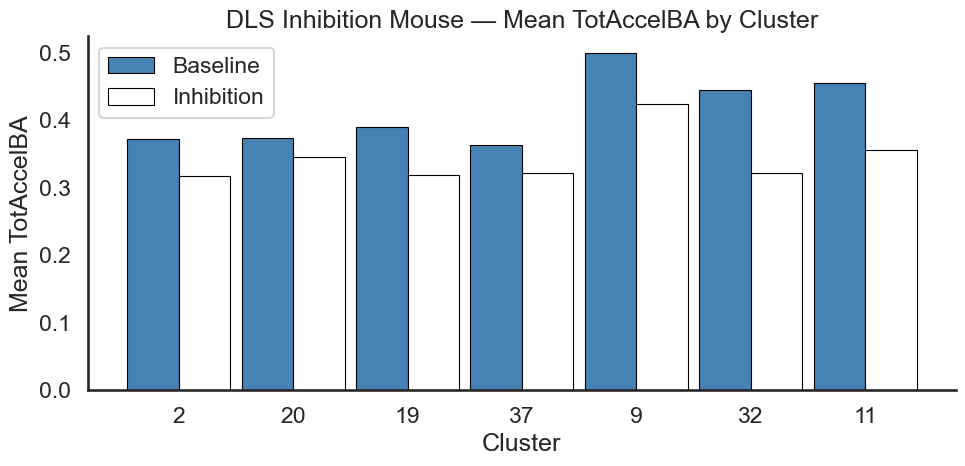

Saved accel CSV to DLS Inhibition Mouse_TotAccelBA_accel.csv


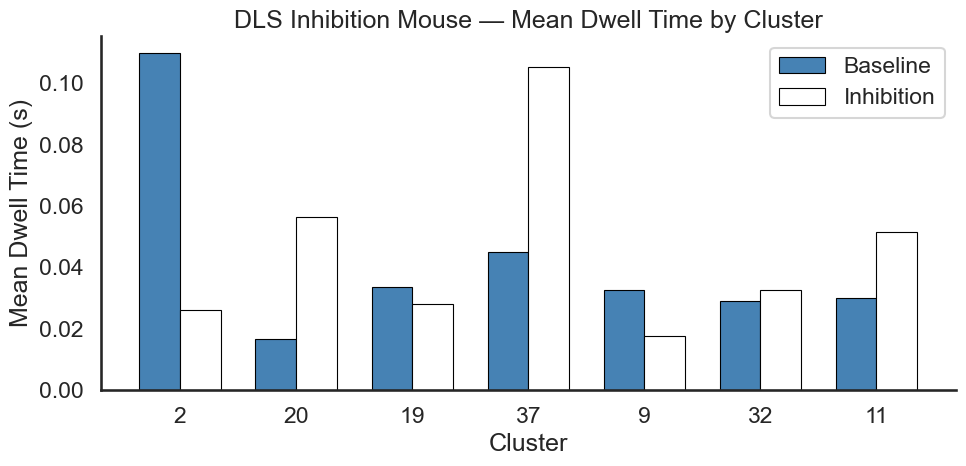

Saved dwell CSV to DLS Inhibition Mouse_Dwell_Time_dwell.csv


,Cluster,Baseline Mean Dwell (s),Inhibition Mean Dwell (s)
0,2,0.109867,0.026026
1,20,0.016653,0.056582
2,19,0.033712,0.028006
3,37,0.044961,0.105422
4,9,0.032606,0.017606
5,32,0.029135,0.032732
6,11,0.029961,0.051414


In [126]:
cluster_labels = [2, 20, 19, 37, 9, 32, 11]
mouse_name = "DLS Inhibition Mouse"
plot_cluster_accel(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_TotAccelBA.png")
plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_Dwell_Time.png")